<a href="https://www.kaggle.com/code/sonawanelalitsunil/income-insights?scriptVersionId=228828924" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/income-survey-finance-analysis/Income_Dataset_Dictionary.docx
/kaggle/input/income-survey-finance-analysis/Income Survey Dataset.csv


## Title: Income Insights

#### Description: Analyze income trends and financial patterns with data-driven insights.

### Import dataset

In [2]:
df = pd.read_csv('/kaggle/input/income-survey-finance-analysis/Income Survey Dataset.csv')

In [3]:
df.head()

,PersonID,Weight,Province,MBMREGP,Age_gap,Gender,Marital_status,Highschool,Highest_edu,Work_ref,...,Pension,Self_emp_income.1,Total_income,Emp_insurance,Salary_wages,compensation,Family_mem,CFCOMP,CONDMP,RENTM
0,1,139.6500,59,38,15,2,3,1,3,2,...,0,0,20275,0,0,0,1,1,99999996,99999996
1,2,254.1041,35,17,9,1,1,1,2,1,...,0,0,110875,0,106000,0,4,4,99999996,99999996
2,3,254.1041,35,17,9,2,1,1,3,1,...,0,0,110875,0,106000,0,4,4,99999996,99999996
3,4,254.1041,35,17,4,1,4,2,1,1,...,0,0,110875,0,106000,0,4,4,99999996,99999996
4,5,254.1041,35,17,3,1,96,6,6,6,...,0,0,110875,0,106000,0,4,4,99999996,99999996


In [4]:
df.tail()

,PersonID,Weight,Province,MBMREGP,Age_gap,Gender,Marital_status,Highschool,Highest_edu,Work_ref,...,Pension,Self_emp_income.1,Total_income,Emp_insurance,Salary_wages,compensation,Family_mem,CFCOMP,CONDMP,RENTM
72638,72639,1603.9917,35,23,5,1,4,1,2,1,...,0,23000,61825,0,28400,0,3,4,99999996,1800
72639,72640,162.6815,24,13,12,2,1,1,3,1,...,103000,0,132400,0,27350,0,3,4,99999996,99999996
72640,72641,162.6815,24,13,13,1,1,1,3,2,...,103000,0,132400,0,27350,0,3,4,99999996,99999996
72641,72642,162.6815,24,13,5,1,4,1,2,2,...,103000,0,132400,0,27350,0,3,4,99999996,99999996
72642,72643,152.8476,24,13,15,2,4,2,1,2,...,525,0,22525,0,0,0,1,1,99999996,400


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72643 entries, 0 to 72642
Data columns (total 38 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   PersonID           72643 non-null  int64  
 1   Weight             72643 non-null  float64
 2   Province           72643 non-null  int64  
 3   MBMREGP            72643 non-null  int64  
 4   Age_gap            72643 non-null  int64  
 5   Gender             72643 non-null  int64  
 6   Marital_status     72643 non-null  int64  
 7   Highschool         72643 non-null  int64  
 8   Highest_edu        72643 non-null  int64  
 9   Work_ref           72643 non-null  int64  
 10  Work_yearly        72643 non-null  int64  
 11  Emp_week_ref       72643 non-null  int64  
 12  Total_hour_ref     72643 non-null  int64  
 13  paid_emp_ref       72643 non-null  int64  
 14  self_emp_ref       72643 non-null  int64  
 15  Immigrant          72643 non-null  int64  
 16  Year_immigrant     726

In [6]:
df.describe()

,PersonID,Weight,Province,MBMREGP,Age_gap,Gender,Marital_status,Highschool,Highest_edu,Work_ref,...,Pension,Self_emp_income.1,Total_income,Emp_insurance,Salary_wages,compensation,Family_mem,CFCOMP,CONDMP,RENTM
count,72643.000000,72643.000000,72643.000000,72643.000000,72643.000000,72643.00000,72643.000000,72643.000000,72643.000000,72643.000000,...,72643.000000,72643.000000,7.264300e+04,72643.000000,7.264300e+04,72643.000000,72643.000000,72643.000000,7.264300e+04,7.264300e+04
mean,36322.000000,507.016134,34.771458,20.433242,9.038201,1.51113,21.930881,2.311537,3.525199,2.167284,...,7665.033107,3901.038641,1.111956e+05,1747.700742,7.777053e+04,427.945914,2.797668,3.542255,9.624879e+07,7.790450e+07
std,20970.372139,622.308449,14.634608,10.755268,4.499854,0.49988,38.486236,2.259477,1.860497,1.826628,...,19847.702036,19728.923744,8.363631e+04,4964.163767,8.109349e+04,3126.157688,1.389884,1.564237,1.900139e+07,4.148903e+07
min,1.000000,10.856700,10.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,...,0.000000,-125000.000000,-9.565000e+04,0.000000,0.000000e+00,0.000000,1.000000,1.000000,0.000000e+00,0.000000e+00
25%,18161.500000,151.937850,24.000000,13.000000,5.000000,1.00000,1.000000,1.000000,2.000000,1.000000,...,0.000000,0.000000,5.568750e+04,0.000000,6.500000e+03,0.000000,2.000000,3.000000,1.000000e+08,1.000000e+08
50%,36322.000000,283.111000,35.000000,19.000000,10.000000,2.00000,3.000000,1.000000,3.000000,1.000000,...,0.000000,0.000000,9.337500e+04,0.000000,6.250000e+04,0.000000,2.000000,4.000000,1.000000e+08,1.000000e+08
75%,54482.500000,605.346400,47.000000,28.000000,13.000000,2.00000,4.000000,2.000000,4.000000,2.000000,...,0.000000,0.000000,1.452000e+05,0.000000,1.200000e+05,0.000000,4.000000,4.000000,1.000000e+08,1.000000e+08
max,72643.000000,8863.955800,59.000000,40.000000,15.000000,2.00000,99.000000,9.000000,9.000000,6.000000,...,369000.000000,400000.000000,2.095000e+06,70000.000000,1.216500e+06,67500.000000,7.000000,9.000000,1.000000e+08,1.000000e+08


In [7]:
df.isnull().sum()

PersonID             0
Weight               0
Province             0
MBMREGP              0
Age_gap              0
Gender               0
Marital_status       0
Highschool           0
Highest_edu          0
Work_ref             0
Work_yearly          0
Emp_week_ref         0
Total_hour_ref       0
paid_emp_ref         0
self_emp_ref         0
Immigrant            0
Year_immigrant       0
income_after_tax     0
Cap_gain             0
Childcare_expe       0
Child_benefit        0
CPP_QPP              0
Earning              0
Guaranteed_income    0
Investment           0
Old_age_pension      0
Private_pension      0
Self_emp_income      0
Pension              0
Self_emp_income.1    0
Total_income         0
Emp_insurance        0
Salary_wages         0
compensation         0
Family_mem           0
CFCOMP               0
CONDMP               0
RENTM                0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.shape

(72643, 38)

In [10]:
df.corr

<bound method DataFrame.corr of        PersonID     Weight  Province  MBMREGP  Age_gap  Gender  \
0             1   139.6500        59       38       15       2   
1             2   254.1041        35       17        9       1   
2             3   254.1041        35       17        9       2   
3             4   254.1041        35       17        4       1   
4             5   254.1041        35       17        3       1   
...         ...        ...       ...      ...      ...     ...   
72638     72639  1603.9917        35       23        5       1   
72639     72640   162.6815        24       13       12       2   
72640     72641   162.6815        24       13       13       1   
72641     72642   162.6815        24       13        5       1   
72642     72643   152.8476        24       13       15       2   

       Marital_status  Highschool  Highest_edu  Work_ref  ...  Pension  \
0                   3           1            3         2  ...        0   
1                   1      

In [11]:
df.dtypes

PersonID               int64
Weight               float64
Province               int64
MBMREGP                int64
Age_gap                int64
Gender                 int64
Marital_status         int64
Highschool             int64
Highest_edu            int64
Work_ref               int64
Work_yearly            int64
Emp_week_ref           int64
Total_hour_ref         int64
paid_emp_ref           int64
self_emp_ref           int64
Immigrant              int64
Year_immigrant         int64
income_after_tax       int64
Cap_gain               int64
Childcare_expe         int64
Child_benefit          int64
CPP_QPP                int64
Earning                int64
Guaranteed_income      int64
Investment             int64
Old_age_pension        int64
Private_pension        int64
Self_emp_income        int64
Pension                int64
Self_emp_income.1      int64
Total_income           int64
Emp_insurance          int64
Salary_wages           int64
compensation           int64
Family_mem    

In [12]:
df.columns

Index(['PersonID', 'Weight', 'Province', 'MBMREGP', 'Age_gap', 'Gender',
       'Marital_status', 'Highschool', 'Highest_edu', 'Work_ref',
       'Work_yearly', 'Emp_week_ref', 'Total_hour_ref', 'paid_emp_ref',
       'self_emp_ref', 'Immigrant', 'Year_immigrant', 'income_after_tax',
       'Cap_gain', 'Childcare_expe', 'Child_benefit', 'CPP_QPP', 'Earning',
       'Guaranteed_income', 'Investment', 'Old_age_pension', 'Private_pension',
       'Self_emp_income', 'Pension', 'Self_emp_income.1', 'Total_income',
       'Emp_insurance', 'Salary_wages', 'compensation', 'Family_mem', 'CFCOMP',
       'CONDMP', 'RENTM'],
      dtype='object')

## Data visualizations

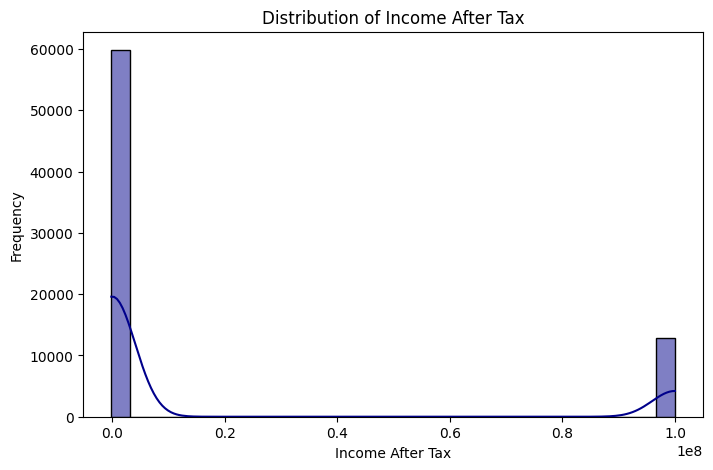

In [13]:
plt.figure(figsize=(8, 5))
sns.histplot(df['income_after_tax'], bins=30, kde=True, color='darkblue')
plt.xlabel('Income After Tax')
plt.ylabel('Frequency')
plt.title('Distribution of Income After Tax')
plt.show()

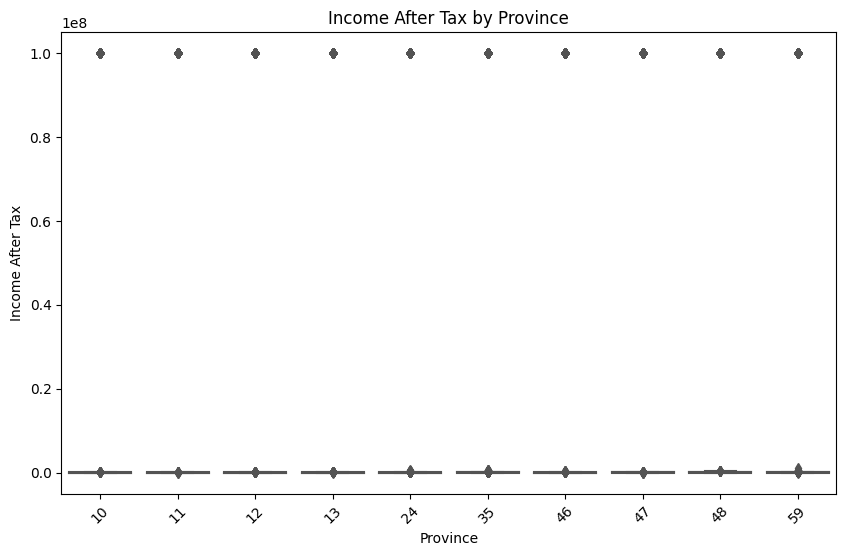

In [14]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Province', y='income_after_tax', data=df, palette='coolwarm')
plt.xticks(rotation=45)
plt.xlabel('Province')
plt.ylabel('Income After Tax')
plt.title('Income After Tax by Province')
plt.show()

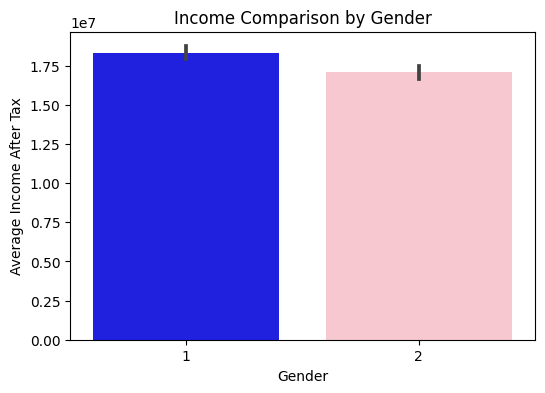

In [15]:
plt.figure(figsize=(6, 4))
sns.barplot(x='Gender', y='income_after_tax', data=df, palette=['blue', 'pink'])
plt.xlabel('Gender')
plt.ylabel('Average Income After Tax')
plt.title('Income Comparison by Gender')
plt.show()


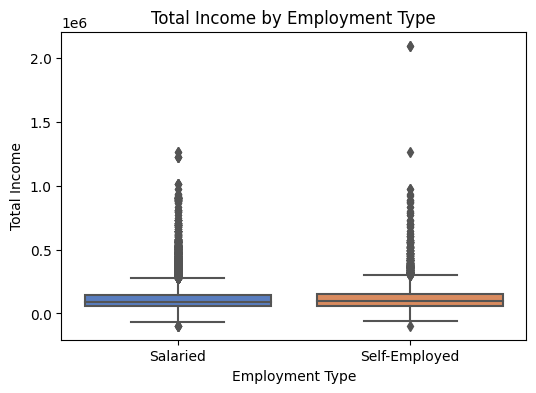

In [16]:
df['Employment Type'] = df['self_emp_ref'].apply(lambda x: 'Self-Employed' if x == 1 else 'Salaried')
plt.figure(figsize=(6, 4))
sns.boxplot(x='Employment Type', y='Total_income', data=df, palette='muted')
plt.xlabel('Employment Type')
plt.ylabel('Total Income')
plt.title('Total Income by Employment Type')
plt.show()


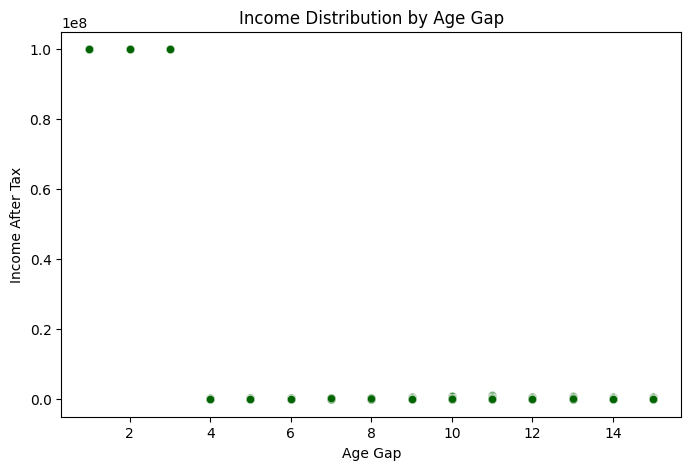

In [17]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Age_gap', y='income_after_tax', data=df, alpha=0.5, color='darkgreen')
plt.xlabel('Age Gap')
plt.ylabel('Income After Tax')
plt.title('Income Distribution by Age Gap')
plt.show()


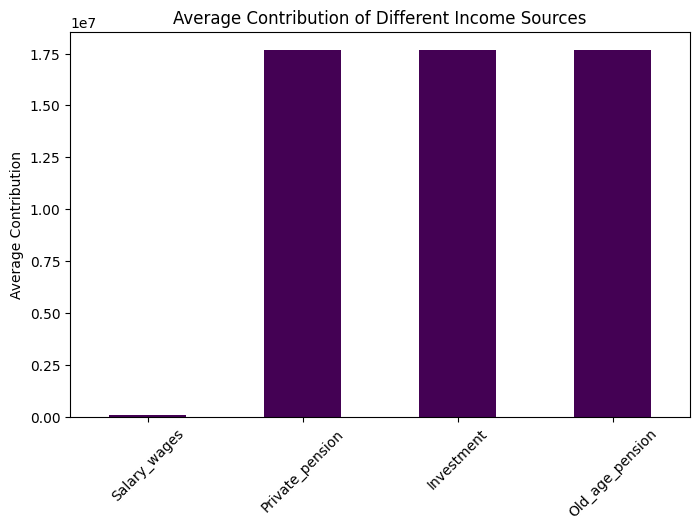

In [18]:
income_sources = df[['Salary_wages', 'Private_pension', 'Investment', 'Old_age_pension']].mean()
income_sources.plot(kind='bar', colormap='viridis', figsize=(8, 5))
plt.ylabel('Average Contribution')
plt.title('Average Contribution of Different Income Sources')
plt.xticks(rotation=45)
plt.show()


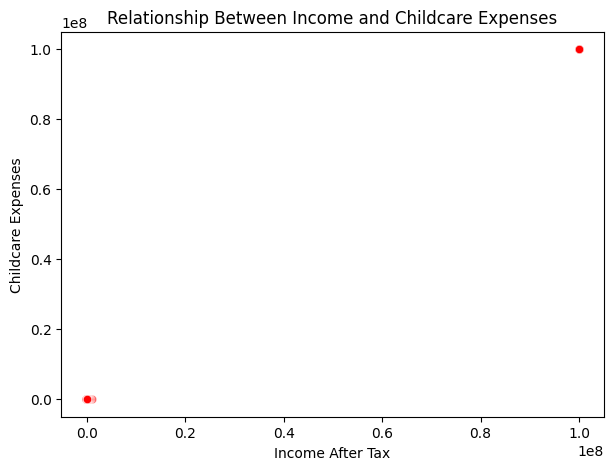

In [19]:
plt.figure(figsize=(7, 5))
sns.scatterplot(x='income_after_tax', y='Childcare_expe', data=df, alpha=0.6, color='red')
plt.xlabel('Income After Tax')
plt.ylabel('Childcare Expenses')
plt.title('Relationship Between Income and Childcare Expenses')
plt.show()


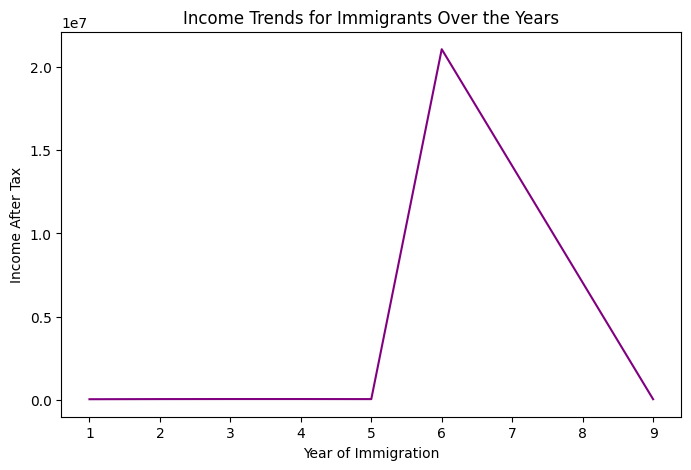

In [20]:
plt.figure(figsize=(8, 5))
sns.lineplot(x='Year_immigrant', y='income_after_tax', data=df, ci=None, color='purple')
plt.xlabel('Year of Immigration')
plt.ylabel('Income After Tax')
plt.title('Income Trends for Immigrants Over the Years')
plt.show()


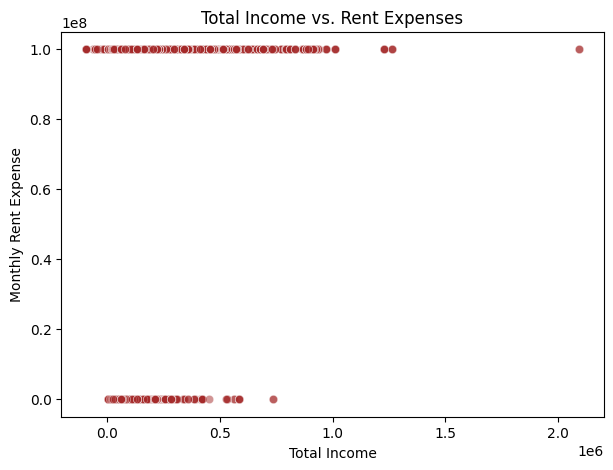

In [21]:
plt.figure(figsize=(7, 5))
sns.scatterplot(x='Total_income', y='RENTM', data=df, alpha=0.5, color='brown')
plt.xlabel('Total Income')
plt.ylabel('Monthly Rent Expense')
plt.title('Total Income vs. Rent Expenses')
plt.show()


## Thankyou...!!!pls upvote!!!